# 05 · Results
Load `results/results.json`, build the per-subset table, and render the figures.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # project root, so `import src` works

In [2]:
import json
import pandas as pd
from src.config import RESULTS
r = json.load(open(RESULTS / 'results.json'))
name = {'C1_ref':'C1 reference','C2_naive':'C2 naive',
        'C3_win_unaware':'C3 unaware','C4_proposed':'C4 proposed'}
subs = ['FD001','FD002','FD003','FD004']
rows = [[s, name[k], round(r[s][k]['auc'],3), round(r[s][k]['ap'],3), round(r[s][k]['f1'],3)]
        for s in subs for k in name]
tbl = pd.DataFrame(rows, columns=['Subset','Config','ROC-AUC','AP','F1'])
tbl

,Subset,Config,ROC-AUC,AP,F1
0,FD001,C1 reference,0.923,0.694,0.645
1,FD001,C2 naive,0.921,0.701,0.659
2,FD001,C3 unaware,0.756,0.313,0.356
3,FD001,C4 proposed,0.937,0.737,0.701
4,FD002,C1 reference,0.884,0.694,0.617
5,FD002,C2 naive,0.894,0.699,0.623
6,FD002,C3 unaware,0.707,0.309,0.318
7,FD002,C4 proposed,0.916,0.714,0.680
8,FD003,C1 reference,0.931,0.652,0.626
9,FD003,C2 naive,0.938,0.677,0.616


Mean over the four subsets:

In [3]:
means = (tbl.groupby('Config', sort=False)[['ROC-AUC','AP','F1']].mean().round(3))
means

,ROC-AUC,AP,F1
Config,,,
C1 reference,0.917,0.687,0.635
C2 naive,0.920,0.698,0.637
C3 unaware,0.753,0.316,0.338
C4 proposed,0.927,0.694,0.647


Rebuild and show the figures:

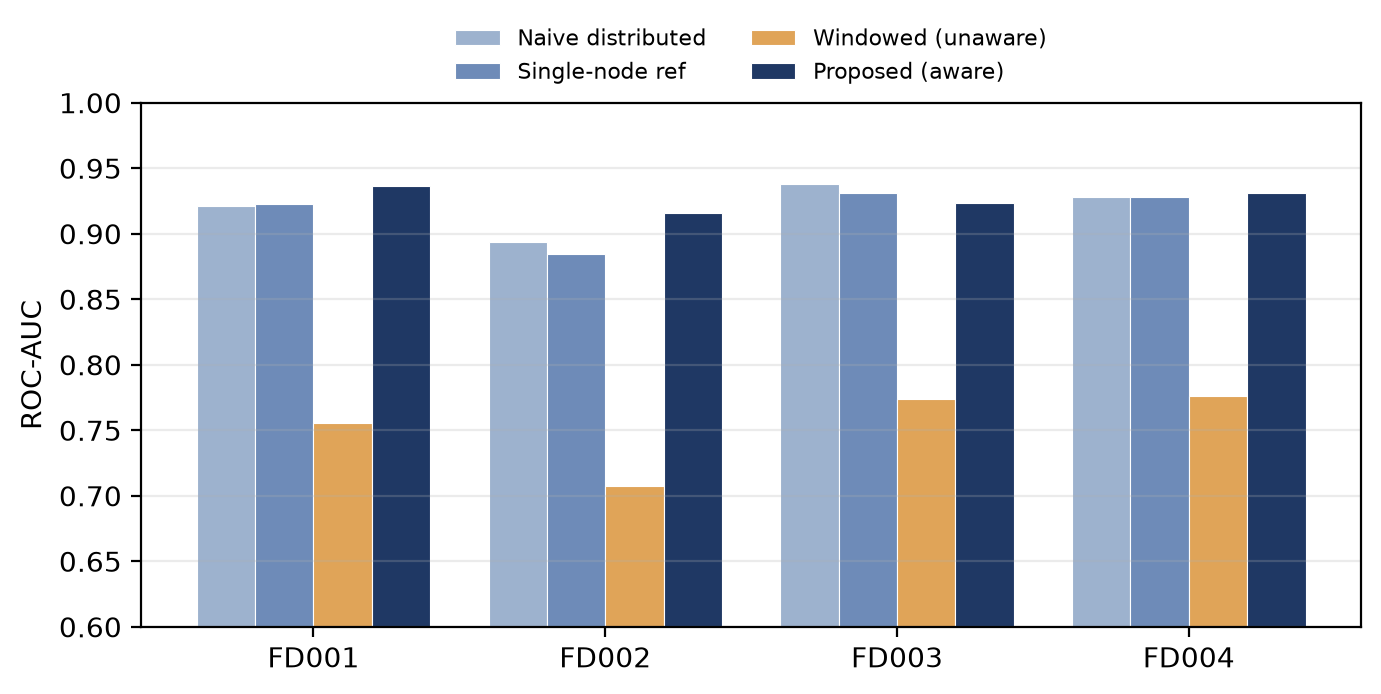

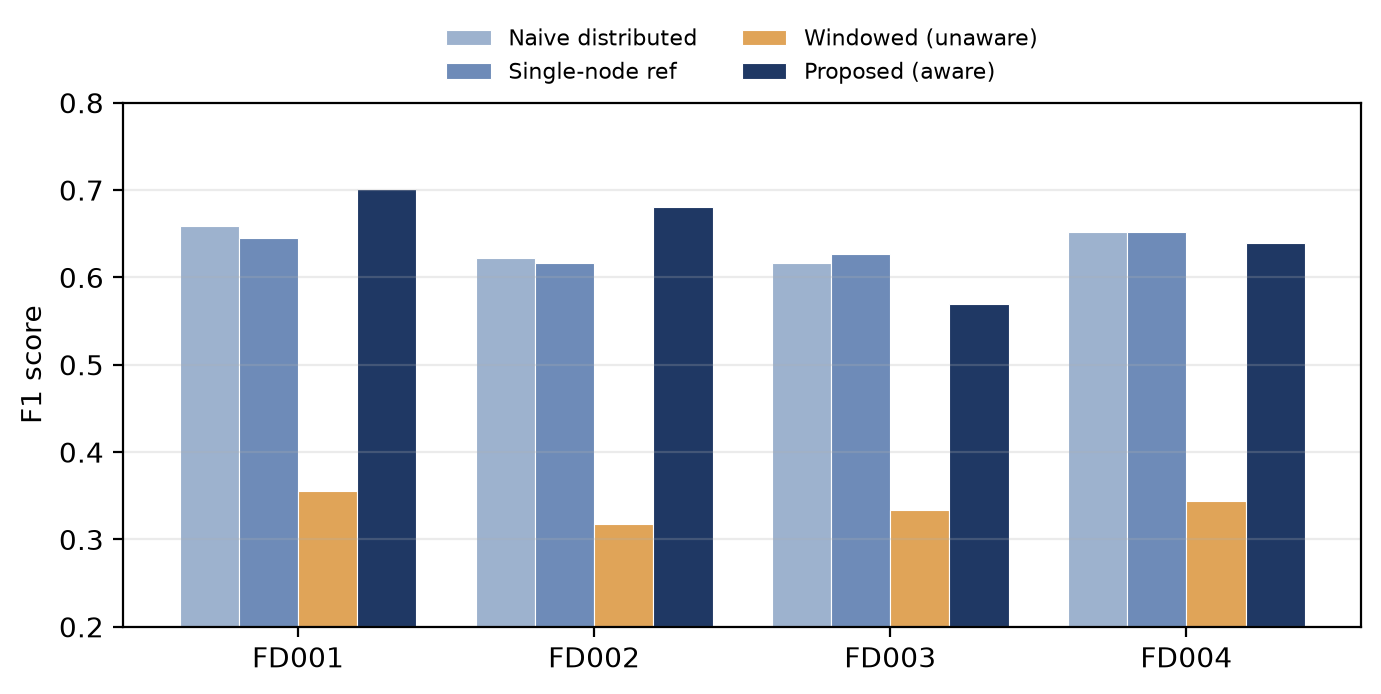

In [4]:
from src.plots import make_detection_figures
from src.config import FIGURES
from IPython.display import Image, display
make_detection_figures()
display(Image(filename=str(FIGURES / 'fig_auc.png')))
display(Image(filename=str(FIGURES / 'fig_f1.png')))

**Reading:** C4 (partition-aware) has the best mean ROC-AUC and F1, and
wins on FD001, FD002, and FD004. The decisive result is the ablation: C3
(identical window features on partition-unaware splits) collapses far below the
naive baseline — so **partition-awareness**, not the window features, is the
source of the gain.